In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import time
from joblib import Parallel, delayed # <-- ИМПОРТИРУЕМ НУЖНЫЕ ИНСТРУМЕНТЫ

# Класс Lorentz (остается без изменений)
class Lorentz:
    def __init__(self, s=10, b=8/3):
        self.s = s
        self.b = b
        self.r = None

    def _derivatives(self, x, y, z, s, r, b):
        dx_dt = s * (y - x)
        dy_dt = x * (r - z) - y
        dz_dt = x * y - b * z
        return dx_dt, dy_dt, dz_dt

    def RK4(self, x, y, z, s, r, b, dt):
        k1_x, k1_y, k1_z = self._derivatives(x, y, z, s, r, b)
        k2_x, k2_y, k2_z = self._derivatives(x + 0.5*dt*k1_x, y + 0.5*dt*k1_y, z + 0.5*dt*k1_z, s, r, b)
        k3_x, k3_y, k3_z = self._derivatives(x + 0.5*dt*k2_x, y + 0.5*dt*k2_y, z + 0.5*dt*k2_z, s, r, b)
        k4_x, k4_y, k4_z = self._derivatives(x + dt*k3_x, y + dt*k3_y, z + dt*k3_z, s, r, b)
        x_new = x + (dt / 6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
        y_new = y + (dt / 6.0) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
        z_new = z + (dt / 6.0) * (k1_z + 2*k2_z + 2*k3_z + k4_z)
        return x_new, y_new, z_new

    def generate(self, dt, steps, r=28, initial_state=(1.0, 1.0, 1.0)):
        self.r = r
        trajectory = np.zeros((steps + 1, 3))
        trajectory[0] = initial_state
        for i in range(steps):
            x, y, z = trajectory[i]
            trajectory[i+1] = self.RK4(x, y, z, self.s, self.r, self.b, dt)
        return trajectory

def dtw_improved(x, y, dist_metric='euclidean'):
    if x.ndim == 1: x = x.reshape(-1, 1)
    if y.ndim == 1: y = y.reshape(-1, 1)
    n, m = len(x), len(y)
    cost_matrix = cdist(x, y, metric=dist_metric)
    acc_cost_matrix = np.full((n + 1, m + 1), np.inf)
    acc_cost_matrix[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = cost_matrix[i-1, j-1]
            acc_cost_matrix[i, j] = cost + min(acc_cost_matrix[i-1, j], acc_cost_matrix[i, j-1], acc_cost_matrix[i-1, j-1])
    distance = acc_cost_matrix[n, m]
    return distance

dt = 0.01
steps = 10000
# Ваш список r_values + еще один для наглядности (всего 5 сравнений)
r_values = [28, 28.0001, 28.1, 27.9, 27.99, 30,28.01]

# Генерируем 3D-траектории Лоренца
lorentz = Lorentz()
trajectories = {}
print("Generating Lorenz trajectories...")
for r in r_values:
    trajectories[r] = lorentz.generate(dt, steps, r)
print("Done.")

# Выбираем эталон и кандидатов для сравнения
reference_1d = trajectories[28][:, 0]
r_to_compare = [r for r in r_values if r != 28]
candidate_series = [trajectories[r][:, 0] for r in r_to_compare]

start_time_seq = time.time()
dtw_distances_seq = {}
for i, r in enumerate(r_to_compare):
    print(f"  Вычисляем DTW для r={r}...")
    dist = dtw_improved(reference_1d, candidate_series[i])
    dtw_distances_seq[r] = dist
end_time_seq = time.time()



# --- ВЫВОД РЕЗУЛЬТАТОВ ---
print("\n--- Результаты вычислений DTW ---")
# Сортируем для красивого вывода
for r, dist in sorted(dtw_distances_seq.items(), key=lambda item: abs(28 - item[0])):
    print(f"r={r}: {dist:.2f}")



Generating Lorenz trajectories...
Done.
  Вычисляем DTW для r=28.0001...
  Вычисляем DTW для r=28.1...
  Вычисляем DTW для r=27.9...
  Вычисляем DTW для r=27.99...
  Вычисляем DTW для r=30...
  Вычисляем DTW для r=28.01...

--- Результаты вычислений DTW ---
r=28.0001: 16386.42
r=27.99: 16994.62
r=28.01: 18952.64
r=28.1: 17823.66
r=27.9: 19479.54
r=30: 20504.81


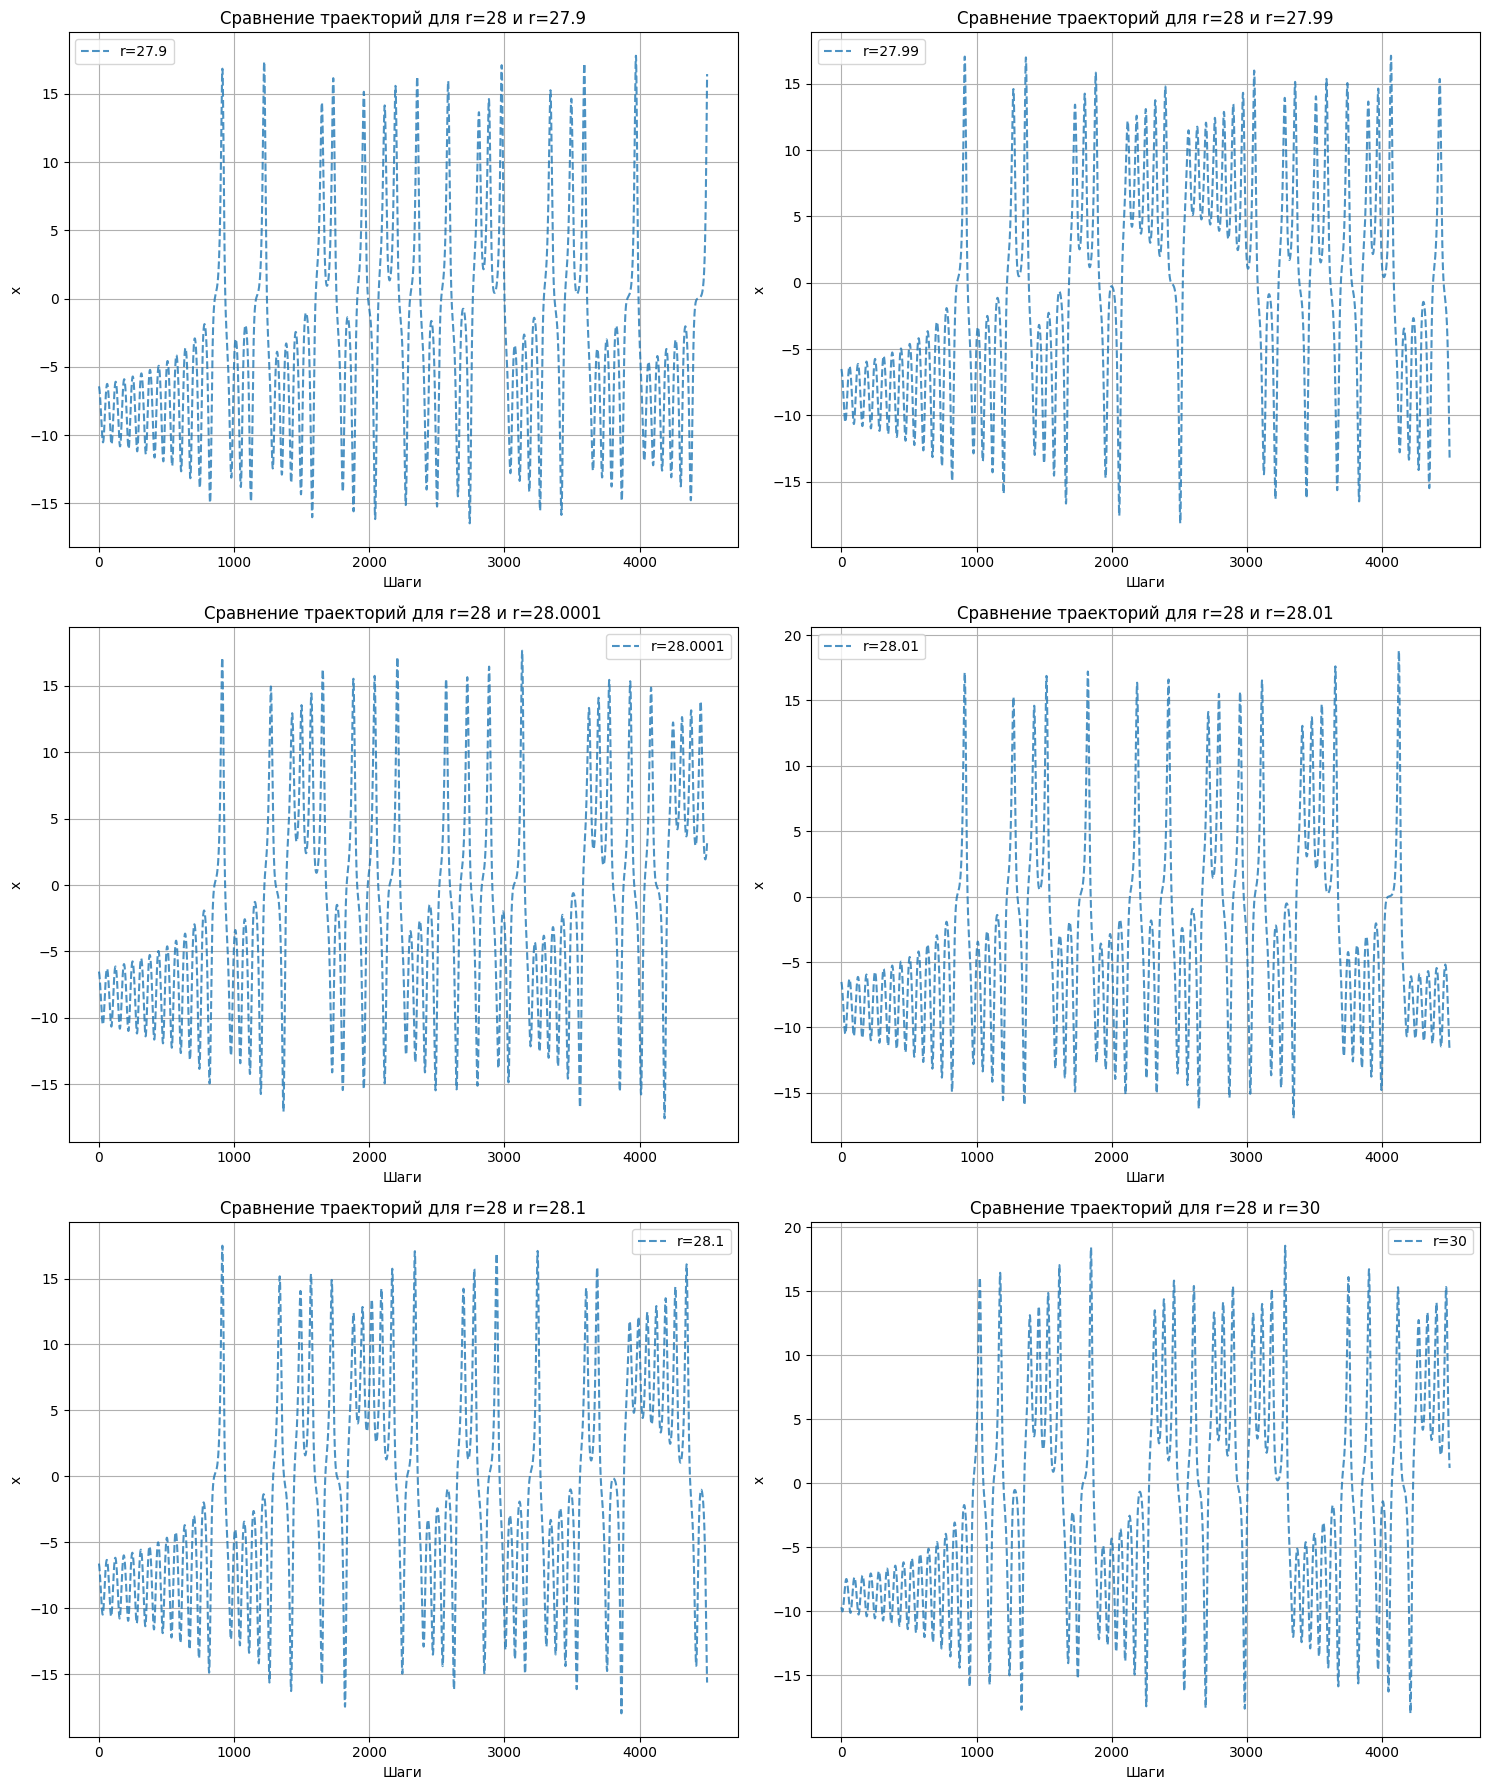

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, b=8/3):
        self.s = s
        self.b = b
        self.r = None

    def _derivatives(self, x, y, z, s, r, b):
        dx_dt = s * (y - x)
        dy_dt = x * (r - z) - y
        dz_dt = x * y - b * z
        return dx_dt, dy_dt, dz_dt

    def RK4(self, x, y, z, s, r, b, dt):
        k1_x, k1_y, k1_z = self._derivatives(x, y, z, s, r, b)
        k2_x, k2_y, k2_z = self._derivatives(x + 0.5*dt*k1_x, y + 0.5*dt*k1_y, z + 0.5*dt*k1_z, s, r, b)
        k3_x, k3_y, k3_z = self._derivatives(x + 0.5*dt*k2_x, y + 0.5*dt*k2_y, z + 0.5*dt*k2_z, s, r, b)
        k4_x, k4_y, k4_z = self._derivatives(x + dt*k3_x, y + dt*k3_y, z + dt*k3_z, s, r, b)
        x_new = x + (dt / 6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
        y_new = y + (dt / 6.0) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
        z_new = z + (dt / 6.0) * (k1_z + 2*k2_z + 2*k3_z + k4_z)
        return x_new, y_new, z_new

    def generate(self, dt, steps, r=28, initial_state=(1.0, 1.0, 1.0)):
        self.r = r
        trajectory = np.zeros((steps + 1, 3))
        trajectory[0] = initial_state
        for i in range(steps):
            x, y, z = trajectory[i]
            trajectory[i+1] = self.RK4(x, y, z, self.s, self.r, self.b, dt)
        return trajectory

# --- ИЗМЕНЕНИЯ НАЧИНАЮТСЯ ЗДЕСЬ ---

# Параметры моделирования
dt = 0.01
steps = 5000
# Отсортируем значения для логичного расположения на графике
r_values_to_compare = sorted([28.0001, 28.1, 27.9, 27.99, 30, 28.01])
initial_state = (1.0, 1.0, 1.0)

# Создаем экземпляр системы Лоренца
lorentz = Lorentz()

# Генерируем эталонную траекторию для r=28
traj_ref = lorentz.generate(dt, steps, r=28, initial_state=initial_state)

# 1. Создаем фигуру и сетку подграфиков (3 ряда, 2 колонки)
# fig - это вся картинка, axes - это массив отдельных окошек для рисования
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))

# Превращаем 2D-массив осей в 1D для удобства итерации
axes = axes.flatten()

# 2. Проходим в цикле по значениям r и соответствующим им осям (ax)
for i, r in enumerate(r_values_to_compare):
    ax = axes[i] # Выбираем текущее "окошко" для рисования

    # Генерируем траекторию для текущего значения r
    traj_comp = lorentz.generate(dt, steps, r=r, initial_state=initial_state)

    # # 3. Рисуем на конкретной оси `ax`, а не на `plt`
    # ax.plot(traj_ref[500:, 0], label='r=28 (эталон)', linewidth=1.5)
    ax.plot(traj_comp[500:, 0], label=f'r={r}', alpha=0.8, linestyle='--')

    ax.set_xlabel('Шаги')
    ax.set_ylabel('x')
    ax.set_title(f'Сравнение траекторий для r=28 и r={r}')
    ax.legend()
    ax.grid(True)

# 4. Автоматически подгоняем расположение, чтобы заголовки не налезали друг на друга
plt.tight_layout()

# 5. Сохраняем всю фигуру целиком в один файл
plt.savefig('rows.png', dpi=150) # dpi для лучшего качества
plt.show()